# Digital Construcion Archive
## Gantenbein Knowledge Graph

This notebook documentes the creation of the Gantenbein Knowledge Graph. The Graph is the foundational structure to connect the RDF Data from the Droid Analysis, to the IFC-Data and further future RDF-Data (Damages, Interventions … )

In this colab notebook you will learn how to make use of the RDFlib library in python and how to create and manipulate RDF graphs with python.
Disclaimer: this document is based on an example used in the course "Knowledge Graphs - Foundations and Applications" by Prof. Dr. Harald Sack

## Setup

**[RDFlib](https://github.com/RDFLib/rdflib)** is is a Python package for working with RDF. It contains:
- parsers and serializers for RDF/XML, N3, NTriples, N-Quads, Turtle, TriX, Trig and JSON-LD
- a graph interface which can be backed by any one of a number of store implementations
- store implementations for in-memory, persistent on disk (Berkeley DB) and remote SPARQL endpoints
- a SPARQL 1.1 implementation - supporting SPARQL 1.1 Queries and Update statements
- SPARQL function extension mechanisms


We have to install the following packages:

*   **RDFlib** for working with RDF
*   **PyDotPlus** for visualization

In [1]:
%%capture
!pip3 install rdflib pydotplus SPARQLWrapper

In [2]:
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD
# for visualization
import io
import re
import pydotplus
from IPython.display import display, Image
from rdflib.tools.rdf2dot import rdf2dot

# Namespaces
CRM = Namespace("http://www.cidoc-crm.org/cidoc-crm/")
DBO = Namespace("http://dbpedia.org/ontology/")
WKD = Namespace("https://www.wikidata.org/wiki/")
AAT = Namespace("http://vocab.getty.edu/aat/")
RICO = Namespace("https://www.ica.org/standards/RiC/ontology#")
PREMIS = Namespace("http://www.loc.gov/premis/rdf/v3/")
DCA_PER = Namespace("https://konstruktionsarchiv.ethz.ch/person/")
DCA_PO = Namespace("https://konstruktionsarchiv.ethz.ch/physical_object/")
DCA_EV = Namespace("https://konstruktionsarchiv.ethz.ch/event/")
DCA_ID = Namespace("https://konstruktionsarchiv.ethz.ch/id/")
DCA_PR = Namespace("https://dca.ethz.ch/procedure/")
DCA_INS = Namespace("https://konstruktionsarchiv.ethz.ch/id/ifc_instance/")
DOCUTEAM = Namespace("http://docuteam.ch/vocab/instantiationcategory/")
BOT = Namespace("https://w3id.org/bot#")


In [3]:
# helper function for visualizing RDF graphs
import re
def visualize(
    g,
    bg_color="#1c1c1c",
    node_fill_color="#1c1c1c",
    node_border_color="#eae8e2",
    edge_color="#eae8e2",
    edge_font_color="#eae8e2",
    edge_penwidth=1.0,
    font_name="Helvetica",
    font_color="#eae8e2",
):
    stream = io.StringIO()
    rdf2dot(g, stream)
    dot_str = stream.getvalue()

    # rdf2dot embeds colors/fonts as hardcoded values in HTML labels;
    # replace them in the DOT string before parsing so all parameters take effect.
    dot_str = dot_str.replace("bgcolor='#eeeeee'", f"bgcolor='{node_fill_color}'")
    dot_str = dot_str.replace("bgcolor='grey'", f"bgcolor='{node_border_color}'")
    dot_str = dot_str.replace("color='#666666'", f"color='{node_border_color}'")
    dot_str = dot_str.replace("color='#6666ff'", f"color='{font_color}'")
    dot_str = dot_str.replace("color='#336633'", f"color='{edge_font_color}'")
    dot_str = re.sub(r'\bcolor=BLACK\b', f'color="{edge_color}"', dot_str)
    dot_str = dot_str.replace('fontname="DejaVu Sans"', f'fontname="{font_name}"')

    dg = pydotplus.graph_from_dot_data(dot_str)
    dg.set_bgcolor(bg_color)

    for edge in dg.get_edges():
        edge.set_penwidth(edge_penwidth)

    png = dg.create_png()
    display(Image(png))

In [4]:
# helper function for visualizing RDF graphs in external files
def visualize_to_file(g, filename):
    stream = io.StringIO()
    rdf2dot(g, stream, opts = {display})
    dot_source = stream.getvalue()
    # Füge die Attribute direkt zur DOT-Quelle hinzu
    dot_source = 'digraph G {\nsize="1000,1000!"; dpi="300"; ratio="fill"; rankdir="LR"; splines="true"; overlap="false";\n' + dot_source[10:]
    src = Source(dot_source)
    src.format = 'png'
    src.render(filename, view=False)
    print(f"Graph wurde in {filename}.png gespeichert.")

## General Information on Gantenbein Vinery

Fabio Gramazio

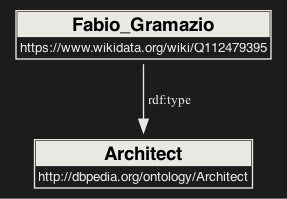

Tripel gesamt: 2


In [5]:
# Base graph
g = Graph()

# Keep readable prefixes in serialize() output
g.bind("crm", CRM)
g.bind("dbo", DBO)
g.bind("wkd", WKD)
g.bind("aat", AAT)
g.bind("rico", RICO)
g.bind("premis", PREMIS)
g.bind("dca-per", DCA_PER)
g.bind("dca-po", DCA_PO)
g.bind("dca-ev", DCA_EV)
g.bind("dca-id", DCA_ID)
g.bind("dca-ins", DCA_INS)
g.bind("dca-pr", DCA_PR)
g.bind("docuteam", DOCUTEAM)

# Fabio Gramazio
g.add((WKD.Q112479395, RDF.type, DBO.Architect))
g.add((WKD.Q112479395, RDFS.label, Literal("Fabio_Gramazio", lang="en")))

visualize(g)
print(f"Tripel gesamt: {len(g)}")


The building and it's designers

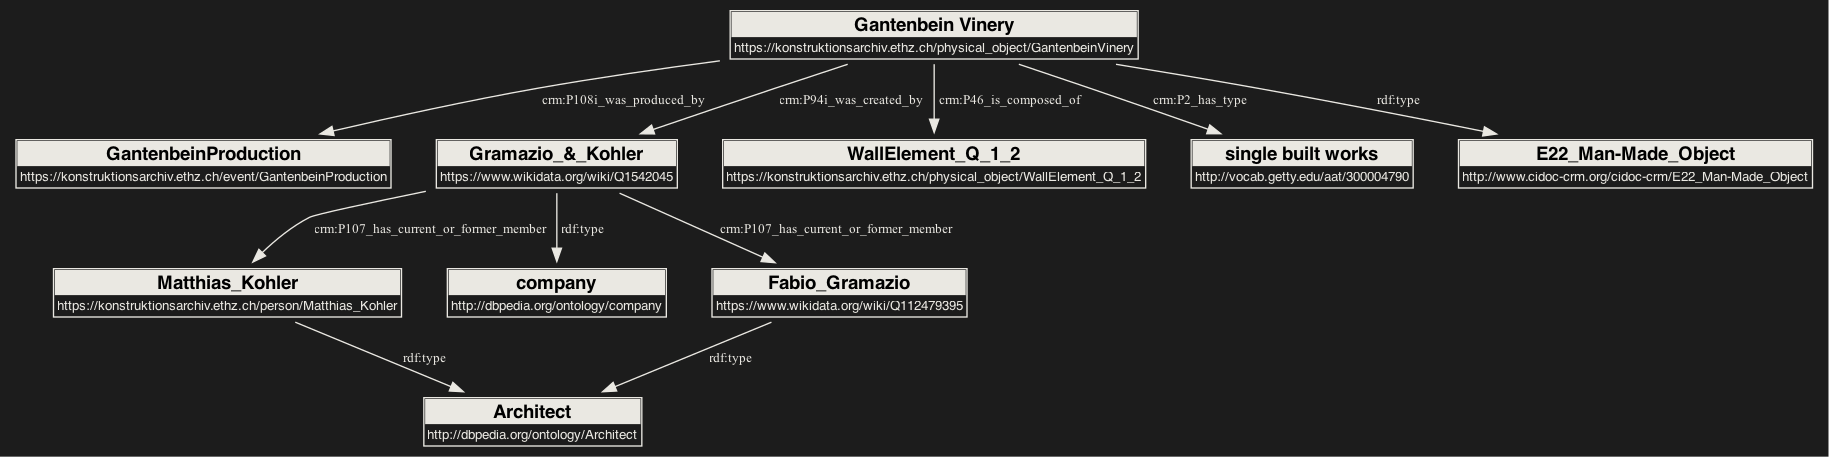

Tripel gesamt: 15


In [6]:
# The building and its designers
g.add((DCA_PER.Matthias_Kohler, RDF.type, DBO.Architect))
g.add((DCA_PER.Matthias_Kohler, RDFS.label, Literal("Matthias_Kohler", lang="en")))

g.add((WKD.Q1542045, RDF.type, DBO.company))
g.add((WKD.Q1542045, RDFS.label, Literal("Gramazio_&_Kohler", lang="en")))
g.add((WKD.Q1542045, CRM.P107_has_current_or_former_member, WKD.Q112479395))
g.add((WKD.Q1542045, CRM.P107_has_current_or_former_member, DCA_PER.Matthias_Kohler))

g.add((DCA_PO.GantenbeinVinery, RDF.type, CRM["E22_Man-Made_Object"]))
g.add((DCA_PO.GantenbeinVinery, RDFS.label, Literal("Gantenbein Vinery", lang="en")))
g.add((DCA_PO.GantenbeinVinery, CRM.P2_has_type, AAT["300004790"]))
g.add((DCA_PO.GantenbeinVinery, CRM.P46_is_composed_of, DCA_PO.WallElement_Q_1_2))
g.add((DCA_PO.GantenbeinVinery, CRM.P108i_was_produced_by, DCA_EV.GantenbeinProduction))
g.add((DCA_PO.GantenbeinVinery, CRM.P94i_was_created_by, WKD.Q1542045))
g.add((AAT["300004790"], RDFS.label, Literal("single built works", lang="en")))

visualize(g)
print(f"Tripel gesamt: {len(g)}")


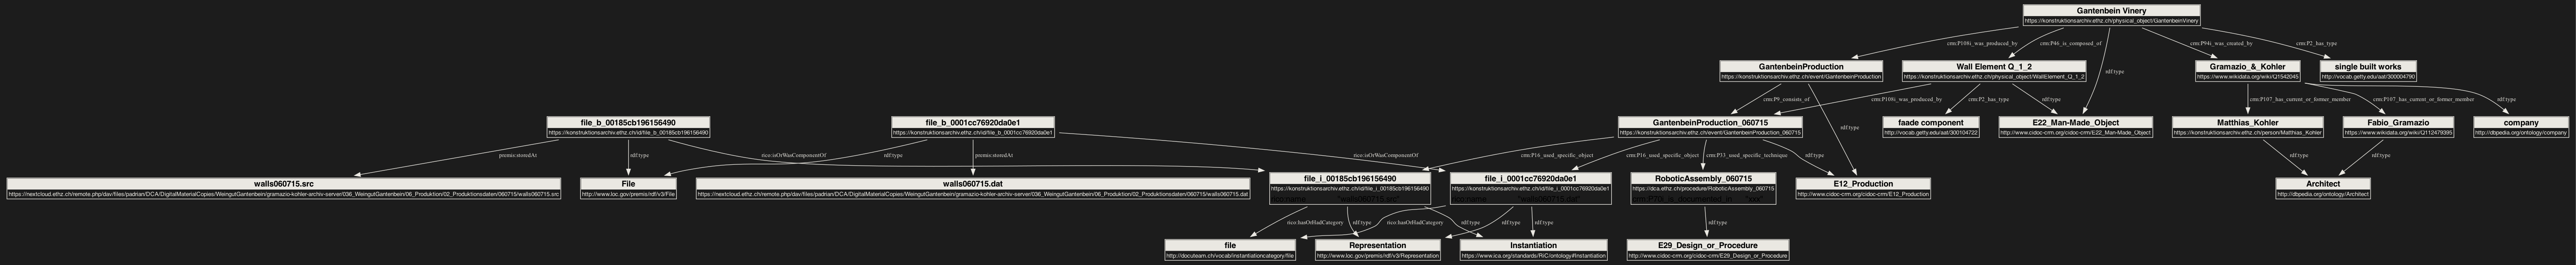

Tripel gesamt: 42


In [7]:
# Production, wall element and files
production_triples = [
    (DCA_PO.WallElement_Q_1_2, RDF.type, CRM["E22_Man-Made_Object"]),
    (DCA_PO.WallElement_Q_1_2, RDFS.label, Literal("Wall Element Q_1_2", lang="en")),
    (DCA_PO.WallElement_Q_1_2, CRM.P2_has_type, AAT["300104722"]),
    (DCA_PO.WallElement_Q_1_2, CRM.P108i_was_produced_by, DCA_EV.GantenbeinProduction_060715),
    (AAT["300104722"], RDFS.label, Literal("faade component", lang="en")),
    (DCA_EV.GantenbeinProduction, RDF.type, CRM.E12_Production),
    (DCA_EV.GantenbeinProduction, CRM.P9_consists_of, DCA_EV.GantenbeinProduction_060715),
    (DCA_EV.GantenbeinProduction_060715, RDF.type, CRM.E12_Production),
    (DCA_EV.GantenbeinProduction_060715, CRM.P33_used_specific_technique, DCA_PR.RoboticAssembly_060715),
    (DCA_EV.GantenbeinProduction_060715, CRM.P16_used_specific_object, DCA_ID.file_i_0001cc76920da0e1),
    (DCA_EV.GantenbeinProduction_060715, CRM.P16_used_specific_object, DCA_ID.file_i_00185cb196156490),
    (DCA_PR.RoboticAssembly_060715, RDF.type, CRM.E29_Design_or_Procedure),
    (DCA_PR.RoboticAssembly_060715, CRM.P70i_is_documented_in, Literal("xxx")),
    (DCA_ID.file_i_0001cc76920da0e1, RDF.type, RICO.Instantiation),
    (DCA_ID.file_i_0001cc76920da0e1, RDF.type, PREMIS.Representation),
    (DCA_ID.file_i_0001cc76920da0e1, RICO.name, Literal("walls060715.dat")),
    (DCA_ID.file_i_0001cc76920da0e1, RICO.hasOrHadCategory, DOCUTEAM.file),
    (DCA_ID.file_i_00185cb196156490, RDF.type, RICO.Instantiation),
    (DCA_ID.file_i_00185cb196156490, RDF.type, PREMIS.Representation),
    (DCA_ID.file_i_00185cb196156490, RICO.name, Literal("walls060715.src")),
    (DCA_ID.file_i_00185cb196156490, RICO.hasOrHadCategory, DOCUTEAM.file),
    (DCA_ID.file_b_0001cc76920da0e1, RDF.type, PREMIS.File),
    (DCA_ID.file_b_0001cc76920da0e1, RICO.isOrWasComponentOf, DCA_ID.file_i_0001cc76920da0e1),
    (DCA_ID.file_b_0001cc76920da0e1, PREMIS.storedAt, URIRef("https://nextcloud.ethz.ch/remote.php/dav/files/padrian/DCA/DigitalMaterialCopies/WeingutGantenbein/gramazio-kohler-archiv-server/036_WeingutGantenbein/06_Produktion/02_Produktionsdaten/060715/walls060715.dat")),
    (DCA_ID.file_b_00185cb196156490, RDF.type, PREMIS.File),
    (DCA_ID.file_b_00185cb196156490, RICO.isOrWasComponentOf, DCA_ID.file_i_00185cb196156490),
    (DCA_ID.file_b_00185cb196156490, PREMIS.storedAt, URIRef("https://nextcloud.ethz.ch/remote.php/dav/files/padrian/DCA/DigitalMaterialCopies/WeingutGantenbein/gramazio-kohler-archiv-server/036_WeingutGantenbein/06_Produktion/02_Produktionsdaten/060715/walls060715.src")),
]

for triple in production_triples:
    g.add(triple)

visualize(g)
print(f"Tripel gesamt: {len(g)}")


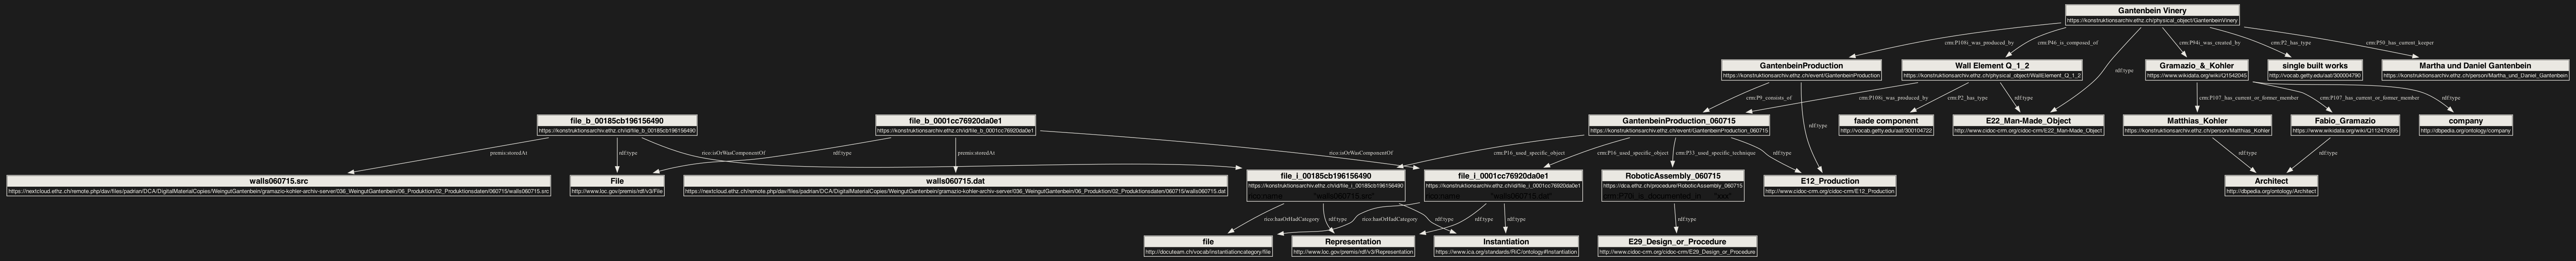

Tripel gesamt: 44


In [8]:
# Add new information to the graph (simple g.add pattern)
g.add((DCA_PO.GantenbeinVinery, CRM.P50_has_current_keeper, DCA_PER.Martha_und_Daniel_Gantenbein))
g.add((DCA_PER.Martha_und_Daniel_Gantenbein, RDFS.label, Literal("Martha und Daniel Gantenbein", lang="de")))

visualize(g)
print(f"Tripel gesamt: {len(g)}")


Tripel im Teilgraph GantenbeinProduction_060715: 16


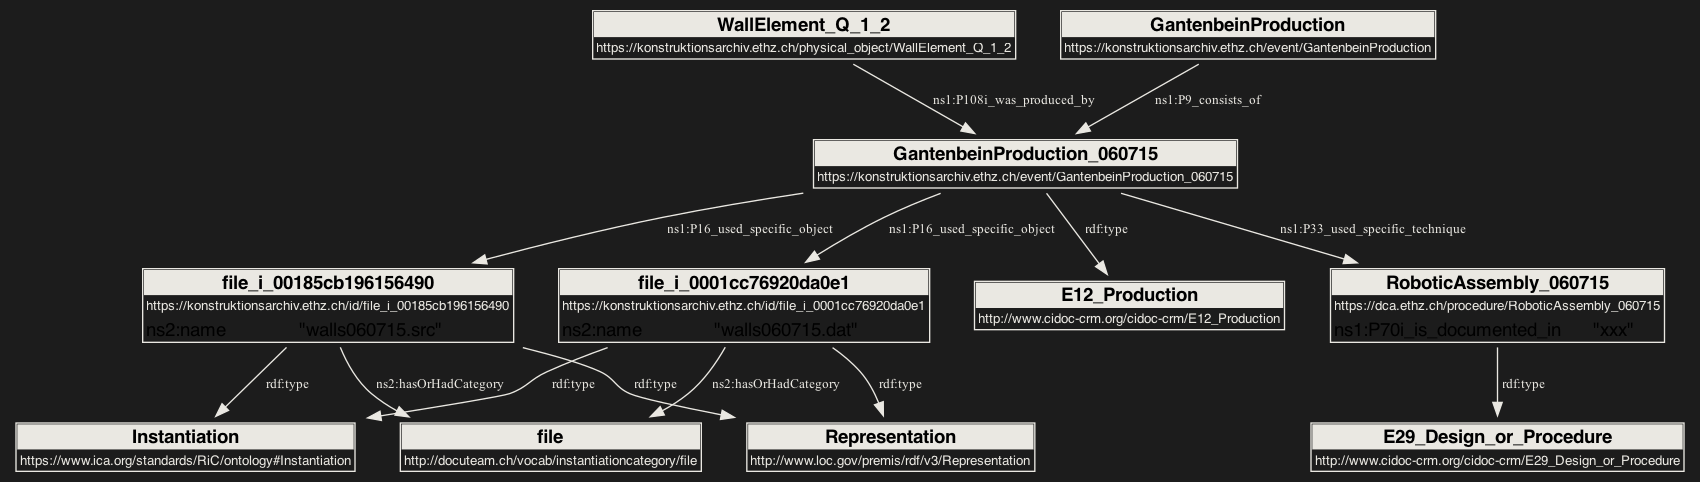

In [9]:
# Query all triples connected to GantenbeinProduction_060715 (1 hop)
query = """
PREFIX crm:    <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX rico:   <https://www.ica.org/standards/RiC/ontology#>
PREFIX premis: <http://www.loc.gov/premis/rdf/v3/>
PREFIX rdfs:   <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dca-ev: <https://konstruktionsarchiv.ethz.ch/event/>

CONSTRUCT {
    ?s ?p ?o .
    ?o ?p2 ?o2 .
}
WHERE {
    {
        # outgoing: GantenbeinProduction_060715 as subject
        BIND(dca-ev:GantenbeinProduction_060715 AS ?s)
        ?s ?p ?o .
        OPTIONAL { ?o ?p2 ?o2 }
    } UNION {
        # incoming: GantenbeinProduction_060715 as object
        ?s ?p dca-ev:GantenbeinProduction_060715 .
        BIND(dca-ev:GantenbeinProduction_060715 AS ?o)
        OPTIONAL { BIND(?p AS ?p2) BIND(?o AS ?o2) }
    }
}
"""

g_060715 = g.query(query).graph
print(f"Tripel im Teilgraph GantenbeinProduction_060715: {len(g_060715)}")
visualize(g_060715)

Add Link to IFC

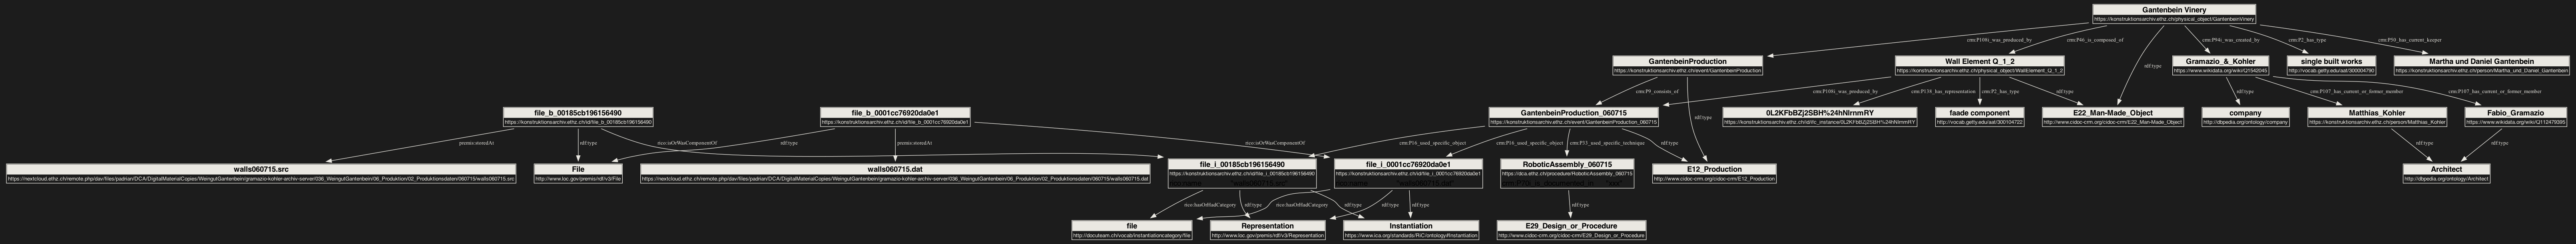

Tripel gesamt: 45


In [10]:
# Wall element in IFC
IFCwall_triples = [
    (DCA_PO.WallElement_Q_1_2, CRM.P138_has_representation, DCA_INS["0L2KFbBZj2SBH%24hNlrnmRY"]),
]

for triple in IFCwall_triples:
    g.add(triple)

visualize(g)
print(f"Tripel gesamt: {len(g)}")



In [11]:
g.serialize("260906_DCA_Gantenbein_Knowledge_Graph.ttl", format="turtle")
print("Serialized.")


Serialized.
